In [1]:
# ============================================================
# BiT-MamSleep Inspired: Triple-CNN + Bidirectional Mamba + SupCon
# Pure PyTorch — NO mamba-ssm library needed
# Windows compatible
#
# Architecture (inspired by BiT-MamSleep, arXiv 2411.01589):
#   1. Triple-Resolution CNN:
#      - Small kernel  (k=25)  → high-freq, alpha/theta (N1)
#      - Medium kernel (k=50)  → mid-range features
#      - Large kernel  (k=100) → slow wave, delta (N3)
#      → concat → project
#   2. Bidirectional Mamba (pure PyTorch SSM):
#      - Forward pass + Backward pass
#      - Captures both past and future context
#      - Better N1 transition detection
#   3. Inter-epoch Bidirectional Mamba:
#      - Context=7 window
#   4. SupCon Loss (λ=0.2, τ=0.05)
#   5. Artifact-Aware Weighted CE Loss
#
# Reference:
#   Zhou et al. "BiT-MamSleep: Bidirectional Temporal Mamba
#   for EEG Sleep Staging" arXiv:2411.01589 (2024)
# ============================================================

import os
import csv
import math
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================
# PATHS & CONFIG
# ============================================================
SAVE_PATH     = r"D:\22\AA\preprocess\preprocessed_FFinal"
ARTIFACT_PATH = r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0\derivatives\eegfloss-v1.0"
EVAL_PATH     = r"D:\22\AA\evaluation\bitMamSleep_supcon_c7"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES   = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT       = 7
WINDOW        = 2 * CONTEXT + 1    # 15
N_EPOCHS      = 30
BATCH_SIZE    = 64
SEEDS         = [42, 123, 256, 789, 999]

# Model config
D_MODEL       = 128
D_STATE       = 16     # Mamba state dimension
DROPOUT       = 0.4

# SupCon
SUPCON_LAMBDA = 0.2
SUPCON_TEMP   = 0.05
PROJ_DIM      = 64

ARTIFACT_WEIGHT_MAP = {0: 1.0, 1: 0.0, 2: 0.4, 3: 0.2, 4: 0.1}
TARGET_CHANNELS     = ["PSG_F3:A2", "PSG_C3:A2"]
FALLBACK_CHANNELS   = ["PSG_F3", "PSG_C3", "Zmax_EEGL", "Zmax_EEGR"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"Seeds         : {SEEDS}")
print(f"Context       : {CONTEXT} (window={WINDOW})")
print(f"Architecture  : Triple-CNN + BiMamba + SupCon")
print(f"SupCon λ={SUPCON_LAMBDA}, τ={SUPCON_TEMP}")
print(f"Output        : {EVAL_PATH}")


# ============================================================
# ARTIFACT WEIGHT LOADER
# ============================================================
def load_artifact_weights(subject_id, artifact_path, epoch_duration=30):
    tsv_path = os.path.join(
        artifact_path, subject_id, "eeg",
        f"{subject_id}_task-sleep_proc-artifacts.tsv"
    )
    if not os.path.exists(tsv_path):
        return None
    try:
        df = pd.read_csv(tsv_path, sep='\t')
    except Exception:
        return None

    available = [ch for ch in TARGET_CHANNELS if ch in df.columns]
    if not available:
        available = [ch for ch in FALLBACK_CHANNELS if ch in df.columns]
    if not available:
        return None

    df['worst_score'] = df[available].max(axis=1).astype(int)
    df['sleep_epoch'] = ((df['offset'] - 1e-6) // epoch_duration).astype(int)
    epoch_scores = df.groupby('sleep_epoch')['worst_score'].max()

    n_ep    = int(epoch_scores.index.max()) + 1
    weights = np.ones(n_ep, dtype=np.float32)
    for ep_idx, score in epoch_scores.items():
        weights[int(ep_idx)] = ARTIFACT_WEIGHT_MAP.get(int(score), 1.0)
    return weights


# ============================================================
# FIXED SPLIT
# ============================================================
all_subjects = sorted([
    f.replace(".npz", "")
    for f in os.listdir(SAVE_PATH)
    if f.endswith(".npz") and not f.startswith("_")
])

_train_path = os.path.join(SAVE_PATH, "_train_subs.npy")
_test_path  = os.path.join(SAVE_PATH, "_test_subs.npy")

if os.path.exists(_train_path) and os.path.exists(_test_path):
    TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
    TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
    print(f"Split loaded -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")
else:
    _subs = all_subjects.copy()
    random.seed(42)
    random.shuffle(_subs)
    n          = int(0.8 * len(_subs))
    TRAIN_SUBS = _subs[:n]
    TEST_SUBS  = _subs[n:]
    np.save(_train_path, np.array(TRAIN_SUBS))
    np.save(_test_path,  np.array(TEST_SUBS))
    print(f"Split created -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")

print(f"TEST_SUBS: {TEST_SUBS}")


# ============================================================
# DATASET
# ============================================================
class ArtifactAwareDataset(Dataset):
    def __init__(self, subject_list, data_path,
                 artifact_path, context=CONTEXT):
        self.context = context
        self.data    = []
        self.index   = []

        label_counter  = Counter()
        weight_counter = Counter()
        no_tsv_count   = 0

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0],    :]
                signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                labels = d['labels'].copy()

            n     = len(labels)
            art_w = load_artifact_weights(sub, artifact_path)
            if art_w is None:
                art_w        = np.ones(n, dtype=np.float32)
                no_tsv_count += 1
            else:
                if len(art_w) >= n:
                    art_w = art_w[:n]
                else:
                    pad   = np.ones(n - len(art_w), dtype=np.float32)
                    art_w = np.concatenate([art_w, pad])

            sub_idx = len(self.data)
            self.data.append((signal, labels))

            for i in range(n):
                w = float(art_w[i])
                self.index.append((sub_idx, i, n, w))
                label_counter[int(labels[i])] += 1
                weight_counter[round(w, 1)]   += 1

        self.label_counts = np.array(
            [label_counter[i] for i in range(5)], dtype=np.float32
        )

        total = len(self.index)
        ram   = sum(s.nbytes for s, _ in self.data) / 1e9
        print(f"  Samples  : {total:,}")
        print(f"  RAM      : {ram:.2f} GB")
        print(f"  No TSV   : {no_tsv_count} subjects")
        print(f"  Weight distribution:")
        for w in sorted(weight_counter.keys(), reverse=True):
            pct = weight_counter[w] / total * 100
            print(f"    w={w:.1f} : {weight_counter[w]:>7,} ({pct:.1f}%)")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        signal, labels = self.data[sub_idx]

        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[ei])

        x = np.stack(window_epochs, axis=0)
        y = int(labels[center_i])
        return (
            torch.FloatTensor(x),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32)
        )


# ============================================================
# BUILD DATASETS
# ============================================================
print("\nBuilding datasets...")
train_ds = ArtifactAwareDataset(TRAIN_SUBS, SAVE_PATH, ARTIFACT_PATH)
print()
test_ds  = ArtifactAwareDataset(TEST_SUBS,  SAVE_PATH, ARTIFACT_PATH)
print("Datasets ready.")


# ============================================================
# TRIPLE-RESOLUTION CNN
# BiT-MamSleep: small/medium/large kernel parallel branches
# ============================================================
class TripleResCNN(nn.Module):
    """
    3 parallel CNN branches with different kernel sizes.
    Small  (k=25):  high-freq → alpha/theta → N1 detection
    Medium (k=50):  mid-range → baseline
    Large  (k=100): low-freq  → delta wave → N3 detection
    → concat → project to d_model
    """
    def __init__(self, in_ch=3, d_model=D_MODEL, dropout=DROPOUT):
        super().__init__()
        mid = d_model // 3  # 42 per branch

        def branch(kernel):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=kernel,
                          stride=6, padding=kernel // 2),
                nn.BatchNorm1d(mid), nn.GELU(),
                nn.MaxPool1d(4, 4),
                nn.Conv1d(mid, mid, kernel_size=8, padding=4),
                nn.BatchNorm1d(mid), nn.GELU(),
                nn.MaxPool1d(2, 2),
                nn.Dropout(dropout),
            )

        self.small  = branch(25)
        self.medium = branch(50)
        self.large  = branch(100)

        # Compute output lengths
        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, 3000)
            L_s = self.small(dummy).shape[2]
            L_m = self.medium(dummy).shape[2]
            L_l = self.large(dummy).shape[2]

        # Align all to same length
        target_L = min(L_s, L_m, L_l)
        self.pool_s = nn.AdaptiveAvgPool1d(target_L)
        self.pool_m = nn.AdaptiveAvgPool1d(target_L)
        self.pool_l = nn.AdaptiveAvgPool1d(target_L)
        self.out_len = target_L

        # Project concat (3*mid) → d_model
        self.proj = nn.Sequential(
            nn.Conv1d(3 * mid, d_model, kernel_size=1),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )

    def forward(self, x):
        # x: (B, C, T)
        fs = self.pool_s(self.small(x))    # (B, mid, L)
        fm = self.pool_m(self.medium(x))   # (B, mid, L)
        fl = self.pool_l(self.large(x))    # (B, mid, L)
        f  = torch.cat([fs, fm, fl], dim=1)  # (B, 3*mid, L)
        return self.proj(f)                   # (B, d_model, L)


# ============================================================
# PURE PYTORCH MAMBA SSM BLOCK
#
# Simplified SSM (State Space Model) implementation.
# No mamba-ssm library needed — works on Windows.
#
# Based on S4/Mamba selective scan mechanism:
#   h_t = A * h_{t-1} + B * x_t
#   y_t = C * h_t + D * x_t
#
# With selective (input-dependent) B, C parameters.
# ============================================================
class MambaBlock(nn.Module):
    """
    Simplified Mamba-style SSM block.
    Pure PyTorch, no external dependency.

    Input:  (B, L, d_model)
    Output: (B, L, d_model)
    """
    def __init__(self, d_model=D_MODEL, d_state=D_STATE,
                 d_conv=4, expand=2, dropout=DROPOUT):
        super().__init__()
        self.d_model  = d_model
        self.d_state  = d_state
        self.d_inner  = d_model * expand  # expanded dim

        # Input projection
        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)

        # Depthwise conv for local context
        self.conv1d = nn.Conv1d(
            self.d_inner, self.d_inner,
            kernel_size=d_conv, padding=d_conv - 1,
            groups=self.d_inner, bias=True
        )

        # SSM parameters
        self.x_proj  = nn.Linear(self.d_inner, d_state * 2 + 1, bias=False)
        self.dt_proj = nn.Linear(1, self.d_inner, bias=True)

        # A matrix (log parameterization for stability)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0)
        A = A.expand(self.d_inner, -1)
        self.A_log = nn.Parameter(torch.log(A))

        # D skip connection
        self.D = nn.Parameter(torch.ones(self.d_inner))

        # Output projection
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)
        self.dropout  = nn.Dropout(dropout)

    def ssm_scan(self, x, A, B, C, D):
        """
        Simplified SSM scan (parallel scan approximation).
        x: (B, L, d_inner)
        """
        B_size, L, d = x.shape
        N = self.d_state

        # Initialize hidden state
        h = torch.zeros(B_size, d, N, device=x.device, dtype=x.dtype)
        ys = []

        # Sequential scan
        for i in range(L):
            xi = x[:, i, :]          # (B, d)
            Bi = B[:, i, :]          # (B, N)
            Ci = C[:, i, :]          # (B, N)

            # h = A * h + B * x
            h = h * A.unsqueeze(0) + (xi.unsqueeze(-1) * Bi.unsqueeze(1))
            # y = C * h + D * x
            y = (h * Ci.unsqueeze(1)).sum(-1) + D * xi
            ys.append(y)

        return torch.stack(ys, dim=1)   # (B, L, d)

    def forward(self, x):
        """x: (B, L, d_model)"""
        residual = x
        B, L, _ = x.shape

        # Split into z (gate) and x
        xz     = self.in_proj(x)                         # (B, L, 2*d_inner)
        x_, z  = xz.chunk(2, dim=-1)                     # each (B, L, d_inner)

        # Conv for local feature
        x_ = x_.transpose(1, 2)                          # (B, d_inner, L)
        x_ = self.conv1d(x_)[:, :, :L]                   # trim padding
        x_ = x_.transpose(1, 2)                          # (B, L, d_inner)
        x_ = F.silu(x_)

        # Compute SSM params (selective mechanism)
        ssm_params = self.x_proj(x_)                     # (B, L, 2N+1)
        dt_raw, B_param, C_param = ssm_params.split(
            [1, self.d_state, self.d_state], dim=-1
        )

        # dt: softplus for positivity
        dt   = F.softplus(self.dt_proj(dt_raw))          # (B, L, d_inner)

        # A: discretized
        A    = -torch.exp(self.A_log)                    # (d_inner, N)
        A_dt = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0))
        # A_dt: (B, L, d_inner, N) — use mean over L for scan
        A_disc = A_dt.mean(dim=1)                        # (B, d_inner, N)
        A_disc = A_disc.mean(dim=0)                      # (d_inner, N)

        # SSM scan
        y = self.ssm_scan(x_, A_disc, B_param, C_param, self.D)

        # Gate with z
        y = y * F.silu(z)

        # Output projection
        y = self.out_proj(y)
        y = self.dropout(y)

        return self.norm(y + residual)


# ============================================================
# BIDIRECTIONAL MAMBA BLOCK
# Forward + Backward pass, merge by addition
# ============================================================
class BiMambaBlock(nn.Module):
    """
    Bidirectional Mamba:
    Forward Mamba + Backward Mamba → add → LayerNorm

    Captures both past context (forward) and
    future context (backward) — better N1 transition detection.
    """
    def __init__(self, d_model=D_MODEL, d_state=D_STATE,
                 dropout=DROPOUT):
        super().__init__()
        self.forward_mamba  = MambaBlock(d_model, d_state, dropout=dropout)
        self.backward_mamba = MambaBlock(d_model, d_state, dropout=dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (B, L, d_model)
        # Forward
        fwd = self.forward_mamba(x)

        # Backward: flip sequence, process, flip back
        x_flip = torch.flip(x, dims=[1])
        bwd     = self.backward_mamba(x_flip)
        bwd     = torch.flip(bwd, dims=[1])

        # Merge
        return self.norm(fwd + bwd)


# ============================================================
# FULL MODEL: Triple-CNN + BiMamba + SupCon
# ============================================================
class BitMamSleepSupCon(nn.Module):
    """
    BiT-MamSleep inspired architecture with SupCon.

    Pipeline:
    1. Triple-Resolution CNN → epoch features (B*W, d_model, L)
    2. Intra-epoch BiMamba   → temporal features within epoch
    3. Global pooling        → epoch vector (B*W, d_model)
    4. Reshape               → (B, W, d_model)
    5. Inter-epoch BiMamba   → context across epochs
    6. Center epoch          → classify + project (SupCon)
    """
    def __init__(
        self, in_ch=3, d_model=D_MODEL, d_state=D_STATE,
        n_layers=2, dropout=DROPOUT,
        n_classes=5, context=CONTEXT, proj_dim=PROJ_DIM
    ):
        super().__init__()
        self.context = context
        self.d_model  = d_model

        # Triple-Resolution CNN
        self.triple_cnn = TripleResCNN(
            in_ch=in_ch, d_model=d_model, dropout=dropout
        )
        self.intra_seq_len = self.triple_cnn.out_len

        # Intra-epoch BiMamba (n_layers stacked)
        self.intra_bimamba = nn.Sequential(*[
            BiMambaBlock(d_model, d_state, dropout=dropout)
            for _ in range(n_layers)
        ])

        # Inter-epoch BiMamba (context across window)
        self.inter_pos = nn.Parameter(
            torch.randn(1, WINDOW, d_model) * 0.01
        )
        self.inter_bimamba = nn.Sequential(*[
            BiMambaBlock(d_model, d_state, dropout=dropout)
            for _ in range(n_layers)
        ])

        # Classifier
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

        # SupCon projection head
        self.projector = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, proj_dim),
        )

    def forward(self, x):
        """x: (B, W, C, T)"""
        B, W, C, T = x.shape

        # --- Intra-epoch encoding ---
        # CNN
        cnn_out = self.triple_cnn(
            x.view(B * W, C, T)
        )                                         # (B*W, d_model, L)

        # BiMamba expects (batch, seq, d_model)
        cnn_out = cnn_out.permute(0, 2, 1)        # (B*W, L, d_model)
        intra   = self.intra_bimamba(cnn_out)     # (B*W, L, d_model)

        # Global avg pool → epoch vector
        epoch_feat = intra.mean(dim=1)            # (B*W, d_model)
        epoch_feat = epoch_feat.view(B, W, self.d_model)  # (B, W, d_model)

        # --- Inter-epoch encoding ---
        inter = epoch_feat + self.inter_pos       # add positional
        inter = self.inter_bimamba(inter)         # (B, W, d_model)

        # Center epoch
        center = inter[:, self.context, :]        # (B, d_model)

        logits = self.classifier(center)
        proj   = F.normalize(self.projector(center), dim=1)

        return logits, proj


# ============================================================
# SUPERVISED CONTRASTIVE LOSS
# ============================================================
class SupConLoss(nn.Module):
    def __init__(self, temperature=SUPCON_TEMP):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        B      = features.shape[0]
        device = features.device

        sim     = torch.matmul(features, features.T) / self.temperature
        sim_max, _ = torch.max(sim, dim=1, keepdim=True)
        sim     = sim - sim_max.detach()

        labels_row = labels.unsqueeze(1)
        labels_col = labels.unsqueeze(0)
        pos_mask   = (labels_row == labels_col).float()
        self_mask  = torch.eye(B, device=device)
        pos_mask   = pos_mask - self_mask

        denom_mask = 1 - self_mask
        exp_sim    = torch.exp(sim) * denom_mask
        log_prob   = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)

        n_pos       = pos_mask.sum(dim=1)
        anchor_mask = (n_pos > 0).float()
        loss_per    = -(pos_mask * log_prob).sum(dim=1) / (n_pos + 1e-8)
        return (loss_per * anchor_mask).sum() / (anchor_mask.sum() + 1e-8)


supcon_criterion = SupConLoss(temperature=SUPCON_TEMP)


# ============================================================
# LOSS FUNCTIONS
# ============================================================
def artifact_weighted_ce(logits, labels, weights, class_weights):
    ce    = nn.CrossEntropyLoss(weight=class_weights, reduction='none')(logits, labels)
    w_ce  = ce * weights
    valid = weights > 0
    if valid.sum() == 0:
        return w_ce.mean()
    return w_ce[valid].mean()


def combined_loss(logits, proj, labels, weights, class_weights):
    l_ce     = artifact_weighted_ce(logits, labels, weights, class_weights)
    l_supcon = supcon_criterion(proj, labels)
    return l_ce + SUPCON_LAMBDA * l_supcon, l_ce.item(), l_supcon.item()


# ============================================================
# CLASS WEIGHTS
# ============================================================
cw_np = train_ds.label_counts.sum() / (5 * train_ds.label_counts)
cw    = torch.FloatTensor(cw_np).to(device)
print(f"\nClass weights:")
for name, w in zip(LABEL_NAMES, cw_np):
    print(f"  {name}: {w:.3f}")


# ============================================================
# HELPERS
# ============================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


# ============================================================
# TRAIN FUNCTION
# ============================================================
def train_epoch_fn(model, loader, optimizer, scheduler):
    model.train()
    total_loss = total_ce = total_sc = 0
    preds, labs = [], []

    for i, (x, y, w) in enumerate(loader):
        x, y, w = x.to(device), y.to(device), w.to(device)
        optimizer.zero_grad()

        logits, proj = model(x)
        loss, l_ce, l_sc = combined_loss(logits, proj, y, w, cw)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        total_ce   += l_ce
        total_sc   += l_sc
        preds.extend(logits.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())

        if (i + 1) % 300 == 0:
            print(f"  batch {i+1}/{len(loader)}", end="\r")

    n   = len(loader)
    acc = accuracy_score(labs, preds)
    f1  = f1_score(labs, preds, average='macro', zero_division=0)
    return total_loss / n, total_ce / n, total_sc / n, acc, f1


# ============================================================
# EVAL FUNCTION
# ============================================================
def evaluate_fn(model, loader):
    model.eval()
    preds, labs, weights_all = [], [], []

    with torch.no_grad():
        for x, y, w in loader:
            logits, _ = model(x.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(y.numpy())
            weights_all.extend(w.numpy())

    preds       = np.array(preds)
    labs        = np.array(labs)
    weights_all = np.array(weights_all)

    acc     = accuracy_score(labs, preds)
    f1      = f1_score(labs, preds, average='macro', zero_division=0)
    kappa   = cohen_kappa_score(labs, preds)
    per_cls = f1_score(labs, preds, average=None, zero_division=0)

    clean_mask = weights_all == 1.0
    noisy_mask = (weights_all > 0) & (weights_all < 1.0)
    clean_acc  = accuracy_score(labs[clean_mask], preds[clean_mask]) if clean_mask.sum() > 0 else 0.0
    noisy_acc  = accuracy_score(labs[noisy_mask], preds[noisy_mask]) if noisy_mask.sum() > 0 else 0.0

    return (acc, f1, kappa, per_cls, preds, labs,
            clean_acc, noisy_acc,
            int(clean_mask.sum()), int(noisy_mask.sum()))


# ============================================================
# CSV SETUP
# ============================================================
csv_epoch_path = os.path.join(EVAL_PATH, "all_seeds_epoch_log.csv")
with open(csv_epoch_path, 'w', newline='') as f:
    csv.writer(f).writerow([
        'seed', 'epoch',
        'tr_loss', 'tr_ce', 'tr_supcon', 'tr_acc', 'tr_f1',
        'vl_acc', 'vl_f1', 'vl_kappa', 'clean_acc', 'noisy_acc'
    ])

csv_summary_path = os.path.join(EVAL_PATH, "summary.csv")
fields = ["seed", "acc", "f1_macro", "kappa",
          "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM",
          "clean_acc", "noisy_acc"]
with open(csv_summary_path, 'w', newline='') as f:
    csv.DictWriter(f, fields).writeheader()


# ============================================================
# 5-SEED TRAINING LOOP
# ============================================================
all_seed_results = []

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"SEED {seed}  ({seed_idx + 1}/{len(SEEDS)})")
    print(f"{'='*60}")

    set_seed(seed)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(seed)
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=0
    )

    model    = BitMamSleepSupCon(in_ch=3).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters : {n_params:,}")

    optimizer   = optim.AdamW(
        model.parameters(),
        lr=5e-4, weight_decay=3e-4,
        betas=(0.9, 0.98), eps=1e-9
    )
    total_steps  = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=warmup_cosine
    )

    best_f1   = 0.0
    best_path = os.path.join(EVAL_PATH, f"best_seed{seed}.pt")
    history   = []

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_ce, tr_sc, tr_acc, tr_f1 = train_epoch_fn(
            model, train_loader, optimizer, scheduler
        )
        (vl_acc, vl_f1, vl_kap, vl_per,
         _, _, clean_acc, noisy_acc,
         n_clean, n_noisy) = evaluate_fn(model, test_loader)

        saved = ""
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        lr = optimizer.param_groups[0]['lr']
        history.append({
            'epoch': epoch,
            'tr_loss': tr_loss, 'tr_ce': tr_ce, 'tr_sc': tr_sc,
            'tr_acc': tr_acc,   'tr_f1': tr_f1,
            'vl_acc': vl_acc,   'vl_f1': vl_f1, 'vl_kap': vl_kap,
            'clean_acc': clean_acc, 'noisy_acc': noisy_acc
        })

        print(
            f"  Ep[{epoch:02d}/{N_EPOCHS}] "
            f"Loss:{tr_loss:.3f}(CE:{tr_ce:.3f}+SC:{tr_sc:.3f}) "
            f"TrAcc:{tr_acc:.3f} ValAcc:{vl_acc:.3f} "
            f"F1:{vl_f1:.3f} k:{vl_kap:.3f} LR:{lr:.2e}{saved}"
        )

        if epoch % 10 == 0:
            print("    Per-class F1: " + " | ".join(
                f"{LABEL_NAMES[i]}={vl_per[i]:.3f}" for i in range(5)
            ))
            print(f"    Clean:{clean_acc:.3f}({n_clean})  "
                  f"Noisy:{noisy_acc:.3f}({n_noisy})")

        with open(csv_epoch_path, 'a', newline='') as f:
            csv.writer(f).writerow([
                seed, epoch,
                f"{tr_loss:.4f}", f"{tr_ce:.4f}", f"{tr_sc:.4f}",
                f"{tr_acc:.4f}", f"{tr_f1:.4f}",
                f"{vl_acc:.4f}", f"{vl_f1:.4f}", f"{vl_kap:.4f}",
                f"{clean_acc:.4f}", f"{noisy_acc:.4f}"
            ])

    # Final eval
    model.load_state_dict(torch.load(best_path, map_location=device))
    (fin_acc, fin_f1, fin_kap, fin_per,
     fin_preds, fin_labels,
     fin_clean_acc, fin_noisy_acc,
     fin_n_clean, fin_n_noisy) = evaluate_fn(model, test_loader)

    print(f"\n  Seed {seed} FINAL:")
    print(f"  {'='*51}")
    print(f"  Accuracy    : {fin_acc*100:.2f}%")
    print(f"  Macro F1    : {fin_f1:.4f}")
    print(f"  Cohen Kappa : {fin_kap:.4f}")
    print(f"  Clean Acc   : {fin_clean_acc*100:.2f}% ({fin_n_clean} epochs)")
    print(f"  Noisy Acc   : {fin_noisy_acc*100:.2f}% ({fin_n_noisy} epochs)")
    print(f"  {'-'*51}")
    print("  Per-class F1:")
    for i, name in enumerate(LABEL_NAMES):
        bar = chr(9608) * int(fin_per[i] * 16)
        print(f"    {name:6s}: {fin_per[i]:.4f}  {bar}")
    print(f"  {'='*51}")

    result = {
        'seed': seed, 'acc': fin_acc, 'f1': fin_f1, 'kappa': fin_kap,
        'per_cls': fin_per,
        'clean_acc': fin_clean_acc, 'noisy_acc': fin_noisy_acc,
        'preds': fin_preds, 'labels': fin_labels, 'history': history,
    }
    all_seed_results.append(result)

    with open(csv_summary_path, 'a', newline='') as f:
        csv.DictWriter(f, fields).writerow({
            "seed":      seed,
            "acc":       round(fin_acc,    4),
            "f1_macro":  round(fin_f1,     4),
            "kappa":     round(fin_kap,    4),
            "f1_Wake":   round(fin_per[0], 4),
            "f1_N1":     round(fin_per[1], 4),
            "f1_N2":     round(fin_per[2], 4),
            "f1_N3":     round(fin_per[3], 4),
            "f1_REM":    round(fin_per[4], 4),
            "clean_acc": round(fin_clean_acc, 4),
            "noisy_acc": round(fin_noisy_acc, 4),
        })


# ============================================================
# FINAL REPORT
# ============================================================
print(f"\n{'='*60}")
print("5-SEED FINAL REPORT")
print(f"{'='*60}")

accs   = np.array([r['acc']        for r in all_seed_results]) * 100
f1s    = np.array([r['f1']         for r in all_seed_results])
kappas = np.array([r['kappa']      for r in all_seed_results])
n1s    = np.array([r['per_cls'][1] for r in all_seed_results])
c_accs = np.array([r['clean_acc']  for r in all_seed_results]) * 100
n_accs = np.array([r['noisy_acc']  for r in all_seed_results]) * 100

print(f"\n{'Seed':<8} {'Acc%':>7} {'F1':>7} {'Kappa':>7} "
      f"{'N1':>7} {'CleanAcc':>10} {'NoisyAcc':>10}")
print("-" * 60)
for r in all_seed_results:
    print(f"{r['seed']:<8} {r['acc']*100:>7.2f} {r['f1']:>7.4f} "
          f"{r['kappa']:>7.4f} {r['per_cls'][1]:>7.4f} "
          f"{r['clean_acc']*100:>10.2f} {r['noisy_acc']*100:>10.2f}")
print("-" * 60)
print(f"{'Mean':<8} {accs.mean():>7.2f} {f1s.mean():>7.4f} "
      f"{kappas.mean():>7.4f} {n1s.mean():>7.4f} "
      f"{c_accs.mean():>10.2f} {n_accs.mean():>10.2f}")
print(f"{'Std':<8} {accs.std():>7.2f} {f1s.std():>7.4f} "
      f"{kappas.std():>7.4f} {n1s.std():>7.4f} "
      f"{c_accs.std():>10.2f} {n_accs.std():>10.2f}")

print(f"\nPaper format:")
print(f"  Accuracy : {accs.mean():.2f} +- {accs.std():.2f}%")
print(f"  Macro F1 : {f1s.mean():.4f} +- {f1s.std():.4f}")
print(f"  Kappa    : {kappas.mean():.4f} +- {kappas.std():.4f}")
print(f"  N1 F1    : {n1s.mean():.4f} +- {n1s.std():.4f}")

print(f"\nPer-class F1 (mean +- std):")
for i, name in enumerate(LABEL_NAMES):
    vals = np.array([r['per_cls'][i] for r in all_seed_results])
    print(f"  {name:6s}: {vals.mean():.4f} +- {vals.std():.4f}")

# Comparison
print(f"\n{'='*60}")
print("COMPARISON WITH PREVIOUS BEST")
print(f"{'='*60}")
print(f"{'Model':<45} {'Acc%':>7} {'F1':>7} {'N1':>7}")
print("-" * 60)
print(f"{'C7+SupCon λ=0.2 single':<45} {'82.31':>7} {'0.7772':>7} {'0.5146':>7}")
print(f"{'C7+SupCon ensemble (best)':<45} {'83.95':>7} {'0.7971':>7} {'0.5481':>7}")
print(f"{'BiT-MamSleep+SupCon (this)':<45} {accs.mean():>7.2f} {f1s.mean():>7.4f} {n1s.mean():>7.4f}")
print(f"{'='*60}")

# Summary CSV
with open(csv_summary_path, 'a', newline='') as f:
    w = csv.DictWriter(f, fields)
    w.writerow({"seed": "mean",
                "acc":       round(accs.mean()/100, 4),
                "f1_macro":  round(f1s.mean(),      4),
                "kappa":     round(kappas.mean(),    4),
                "f1_Wake":   round(np.mean([r['per_cls'][0] for r in all_seed_results]), 4),
                "f1_N1":     round(np.mean([r['per_cls'][1] for r in all_seed_results]), 4),
                "f1_N2":     round(np.mean([r['per_cls'][2] for r in all_seed_results]), 4),
                "f1_N3":     round(np.mean([r['per_cls'][3] for r in all_seed_results]), 4),
                "f1_REM":    round(np.mean([r['per_cls'][4] for r in all_seed_results]), 4),
                "clean_acc": round(c_accs.mean()/100, 4),
                "noisy_acc": round(n_accs.mean()/100, 4)})

print(f"\nSummary saved: {csv_summary_path}")
print("Done!")

Device        : cuda
Seeds         : [42, 123, 256, 789, 999]
Context       : 7 (window=15)
Architecture  : Triple-CNN + BiMamba + SupCon
SupCon λ=0.2, τ=0.05
Output        : D:\22\AA\evaluation\bitMamSleep_supcon_c7
Split loaded -> Train:76  Test:20
TEST_SUBS: ['sub-121', 'sub-081', 'sub-038', 'sub-035', 'sub-104', 'sub-112', 'sub-007', 'sub-068', 'sub-093', 'sub-014', 'sub-087', 'sub-105', 'sub-017', 'sub-023', 'sub-036', 'sub-040', 'sub-045', 'sub-005', 'sub-019', 'sub-100']

Building datasets...
  Samples  : 71,347
  RAM      : 2.57 GB
  No TSV   : 0 subjects
  Weight distribution:
    w=1.0 :  59,303 (83.1%)
    w=0.4 :     930 (1.3%)
    w=0.2 :   7,686 (10.8%)
    w=0.1 :   3,385 (4.7%)
    w=0.0 :      43 (0.1%)

  Samples  : 19,763
  RAM      : 0.71 GB
  No TSV   : 0 subjects
  Weight distribution:
    w=1.0 :  15,258 (77.2%)
    w=0.4 :     428 (2.2%)
    w=0.2 :   3,306 (16.7%)
    w=0.1 :     771 (3.9%)
Datasets ready.

Class weights:
  Wake: 1.844
  N1: 3.142
  N2: 0.442
 

In [2]:
print("hk")

hk


In [ ]:
# # ★ এই path এ তোমার 5টা best_seed*.pt আছে
# CHECKPOINT_DIR = r"D:\22\AA\evaluation\bitMamSleep_supcon_c7"

# EVAL_PATH      = r"D:\22\AA\evaluation\ensemble_bitMamSleep_supcon_c7"

Device         : cuda
Checkpoint dir : D:\22\AA\evaluation\bitMamSleep_supcon_c7
Output         : D:\22\AA\evaluation\ensemble_bitMamSleep_supcon_c7
Test subjects  : 20

Loading test dataset...
Test samples: 19,763

Loading 5 checkpoints from:
  D:\22\AA\evaluation\bitMamSleep_supcon_c7
  ✓ Loaded: best_seed42.pt
  ✓ Loaded: best_seed123.pt
  ✓ Loaded: best_seed256.pt
  ✓ Loaded: best_seed789.pt
  ✓ Loaded: best_seed999.pt

Ensemble size: 5 models

Running ensemble inference...
  seed=42 done
  seed=123 done
  seed=256 done
  seed=789 done
  seed=999 done

BiT-MamSleep ENSEMBLE RESULT (5 seeds, soft vote)
  Accuracy    : 84.01%
  Macro F1    : 0.8016
  Cohen Kappa : 0.7753
  Clean Acc   : 85.00%
  Noisy Acc   : 80.64%
  Per-class F1:
    Wake  : 0.8309  █████████████
    N1    : 0.5482  ████████
    N2    : 0.8678  █████████████
    N3    : 0.8587  █████████████
    REM   : 0.9026  ██████████████

FINAL COMPARISON TABLE
Model                                            Acc%      F1     

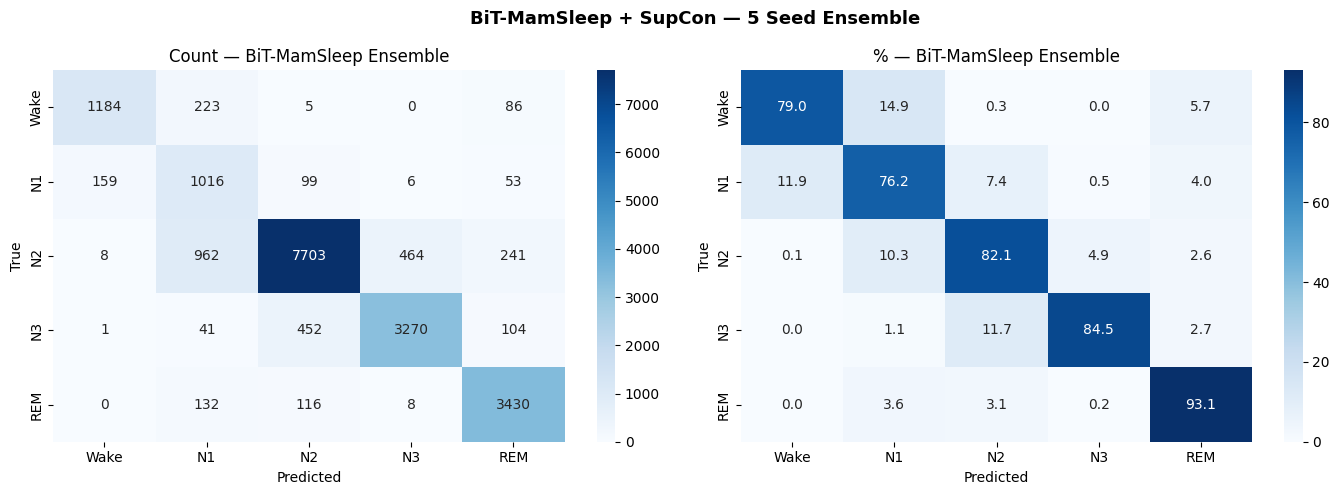


Outputs saved: D:\22\AA\evaluation\ensemble_bitMamSleep_supcon_c7
Done!


In [3]:
# ============================================================
# Ensemble Evaluation — BiT-MamSleep + SupCon (5 seeds)
# ============================================================

import os
import math
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================
# PATHS
# ============================================================
SAVE_PATH      = r"D:\22\AA\preprocess\preprocessed_FFinal"
ARTIFACT_PATH  = r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0\derivatives\eegfloss-v1.0"
CHECKPOINT_DIR = r"D:\22\AA\evaluation\bitMamSleep_supcon_c7"
EVAL_PATH      = r"D:\22\AA\evaluation\ensemble_bitMamSleep_supcon_c7"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 7
WINDOW      = 2 * CONTEXT + 1
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

D_MODEL   = 128
D_STATE   = 16
DROPOUT   = 0.4
PROJ_DIM  = 64

ARTIFACT_WEIGHT_MAP = {0: 1.0, 1: 0.0, 2: 0.4, 3: 0.2, 4: 0.1}
TARGET_CHANNELS     = ["PSG_F3:A2", "PSG_C3:A2"]
FALLBACK_CHANNELS   = ["PSG_F3", "PSG_C3", "Zmax_EEGL", "Zmax_EEGR"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device         : {device}")
print(f"Checkpoint dir : {CHECKPOINT_DIR}")
print(f"Output         : {EVAL_PATH}")


# ============================================================
# ARTIFACT WEIGHT LOADER
# ============================================================
def load_artifact_weights(subject_id, artifact_path, epoch_duration=30):
    tsv_path = os.path.join(
        artifact_path, subject_id, "eeg",
        f"{subject_id}_task-sleep_proc-artifacts.tsv"
    )
    if not os.path.exists(tsv_path):
        return None
    try:
        df = pd.read_csv(tsv_path, sep='\t')
    except Exception:
        return None
    available = [ch for ch in TARGET_CHANNELS if ch in df.columns]
    if not available:
        available = [ch for ch in FALLBACK_CHANNELS if ch in df.columns]
    if not available:
        return None
    df['worst_score'] = df[available].max(axis=1).astype(int)
    df['sleep_epoch'] = ((df['offset'] - 1e-6) // epoch_duration).astype(int)
    epoch_scores = df.groupby('sleep_epoch')['worst_score'].max()
    n_ep    = int(epoch_scores.index.max()) + 1
    weights = np.ones(n_ep, dtype=np.float32)
    for ep_idx, score in epoch_scores.items():
        weights[int(ep_idx)] = ARTIFACT_WEIGHT_MAP.get(int(score), 1.0)
    return weights


# ============================================================
# FIXED TEST SPLIT
# ============================================================
_test_path = os.path.join(SAVE_PATH, "_test_subs.npy")
TEST_SUBS  = np.load(_test_path, allow_pickle=True).tolist()
print(f"Test subjects  : {len(TEST_SUBS)}")


# ============================================================
# DATASET
# ============================================================
class ArtifactAwareDataset(Dataset):
    def __init__(self, subject_list, data_path, artifact_path, context=CONTEXT):
        self.context = context
        self.data    = []
        self.index   = []
        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0],    :]
                signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                labels = d['labels'].copy()
            n     = len(labels)
            art_w = load_artifact_weights(sub, artifact_path)
            if art_w is None:
                art_w = np.ones(n, dtype=np.float32)
            else:
                if len(art_w) >= n:
                    art_w = art_w[:n]
                else:
                    art_w = np.concatenate([art_w, np.ones(n - len(art_w), dtype=np.float32)])
            sub_idx = len(self.data)
            self.data.append((signal, labels))
            for i in range(n):
                self.index.append((sub_idx, i, n, float(art_w[i])))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        signal, labels = self.data[sub_idx]
        window_epochs  = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[ei])
        x = np.stack(window_epochs, axis=0)
        y = int(labels[center_i])
        return (
            torch.FloatTensor(x),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32)
        )


print("\nLoading test dataset...")
test_ds     = ArtifactAwareDataset(TEST_SUBS, SAVE_PATH, ARTIFACT_PATH)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Test samples: {len(test_ds):,}")


# ============================================================
# MODEL CLASSES (same as training)
# ============================================================
class TripleResCNN(nn.Module):
    def __init__(self, in_ch=3, d_model=D_MODEL, dropout=DROPOUT):
        super().__init__()
        mid = d_model // 3

        def branch(kernel):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=kernel,
                          stride=6, padding=kernel // 2),
                nn.BatchNorm1d(mid), nn.GELU(),
                nn.MaxPool1d(4, 4),
                nn.Conv1d(mid, mid, kernel_size=8, padding=4),
                nn.BatchNorm1d(mid), nn.GELU(),
                nn.MaxPool1d(2, 2),
                nn.Dropout(dropout),
            )

        self.small  = branch(25)
        self.medium = branch(50)
        self.large  = branch(100)

        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, 3000)
            L_s = self.small(dummy).shape[2]
            L_m = self.medium(dummy).shape[2]
            L_l = self.large(dummy).shape[2]

        target_L = min(L_s, L_m, L_l)
        self.pool_s  = nn.AdaptiveAvgPool1d(target_L)
        self.pool_m  = nn.AdaptiveAvgPool1d(target_L)
        self.pool_l  = nn.AdaptiveAvgPool1d(target_L)
        self.out_len = target_L

        self.proj = nn.Sequential(
            nn.Conv1d(3 * mid, d_model, kernel_size=1),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )

    def forward(self, x):
        fs = self.pool_s(self.small(x))
        fm = self.pool_m(self.medium(x))
        fl = self.pool_l(self.large(x))
        f  = torch.cat([fs, fm, fl], dim=1)
        return self.proj(f)


class MambaBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, d_state=D_STATE,
                 d_conv=4, expand=2, dropout=DROPOUT):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = d_model * expand

        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d  = nn.Conv1d(
            self.d_inner, self.d_inner,
            kernel_size=d_conv, padding=d_conv - 1,
            groups=self.d_inner, bias=True
        )
        self.x_proj  = nn.Linear(self.d_inner, d_state * 2 + 1, bias=False)
        self.dt_proj = nn.Linear(1, self.d_inner, bias=True)

        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0)
        A = A.expand(self.d_inner, -1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D     = nn.Parameter(torch.ones(self.d_inner))

        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)
        self.dropout  = nn.Dropout(dropout)

    def ssm_scan(self, x, A, B, C, D):
        B_size, L, d = x.shape
        N = self.d_state
        h  = torch.zeros(B_size, d, N, device=x.device, dtype=x.dtype)
        ys = []
        for i in range(L):
            xi = x[:, i, :]
            Bi = B[:, i, :]
            Ci = C[:, i, :]
            h  = h * A.unsqueeze(0) + (xi.unsqueeze(-1) * Bi.unsqueeze(1))
            y  = (h * Ci.unsqueeze(1)).sum(-1) + D * xi
            ys.append(y)
        return torch.stack(ys, dim=1)

    def forward(self, x):
        residual = x
        B, L, _  = x.shape
        xz       = self.in_proj(x)
        x_, z    = xz.chunk(2, dim=-1)
        x_       = x_.transpose(1, 2)
        x_       = self.conv1d(x_)[:, :, :L]
        x_       = x_.transpose(1, 2)
        x_       = F.silu(x_)
        ssm_params           = self.x_proj(x_)
        dt_raw, B_p, C_p     = ssm_params.split([1, self.d_state, self.d_state], dim=-1)
        dt                   = F.softplus(self.dt_proj(dt_raw))
        A                    = -torch.exp(self.A_log)
        A_dt                 = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0))
        A_disc               = A_dt.mean(dim=1).mean(dim=0)
        y                    = self.ssm_scan(x_, A_disc, B_p, C_p, self.D)
        y                    = y * F.silu(z)
        y                    = self.out_proj(y)
        y                    = self.dropout(y)
        return self.norm(y + residual)


class BiMambaBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, d_state=D_STATE, dropout=DROPOUT):
        super().__init__()
        self.forward_mamba  = MambaBlock(d_model, d_state, dropout=dropout)
        self.backward_mamba = MambaBlock(d_model, d_state, dropout=dropout)
        self.norm           = nn.LayerNorm(d_model)

    def forward(self, x):
        fwd    = self.forward_mamba(x)
        x_flip = torch.flip(x, dims=[1])
        bwd    = self.backward_mamba(x_flip)
        bwd    = torch.flip(bwd, dims=[1])
        return self.norm(fwd + bwd)


class BitMamSleepSupCon(nn.Module):
    def __init__(
        self, in_ch=3, d_model=D_MODEL, d_state=D_STATE,
        n_layers=2, dropout=DROPOUT,
        n_classes=5, context=CONTEXT, proj_dim=PROJ_DIM
    ):
        super().__init__()
        self.context = context
        self.d_model = d_model

        self.triple_cnn    = TripleResCNN(in_ch=in_ch, d_model=d_model, dropout=dropout)
        self.intra_bimamba = nn.Sequential(*[
            BiMambaBlock(d_model, d_state, dropout=dropout) for _ in range(n_layers)
        ])
        self.inter_pos     = nn.Parameter(torch.randn(1, WINDOW, d_model) * 0.01)
        self.inter_bimamba = nn.Sequential(*[
            BiMambaBlock(d_model, d_state, dropout=dropout) for _ in range(n_layers)
        ])
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )
        self.projector = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, proj_dim),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        cnn_out    = self.triple_cnn(x.view(B * W, C, T))
        cnn_out    = cnn_out.permute(0, 2, 1)
        intra      = self.intra_bimamba(cnn_out)
        epoch_feat = intra.mean(dim=1).view(B, W, self.d_model)
        inter      = self.inter_bimamba(epoch_feat + self.inter_pos)
        center     = inter[:, self.context, :]
        logits     = self.classifier(center)
        proj       = F.normalize(self.projector(center), dim=1)
        return logits, proj


# ============================================================
# LOAD 5 MODELS
# ============================================================
print(f"\nLoading 5 checkpoints from:\n  {CHECKPOINT_DIR}")
models = []
for seed in SEEDS:
    ckpt = os.path.join(CHECKPOINT_DIR, f"best_seed{seed}.pt")
    if not os.path.exists(ckpt):
        print(f"  ✗ NOT FOUND: best_seed{seed}.pt")
        continue
    m = BitMamSleepSupCon(in_ch=3).to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()
    models.append((seed, m))
    print(f"  ✓ Loaded: best_seed{seed}.pt")

print(f"\nEnsemble size: {len(models)} models")


# ============================================================
# COLLECT LABELS & WEIGHTS
# ============================================================
all_labels  = []
all_weights = []
with torch.no_grad():
    for x, y, w in test_loader:
        all_labels.extend(y.numpy())
        all_weights.extend(w.numpy())
all_labels  = np.array(all_labels)
all_weights = np.array(all_weights)


# ============================================================
# INFERENCE
# ============================================================
print("\nRunning ensemble inference...")
all_probs = []
for seed, model in models:
    model_probs = []
    with torch.no_grad():
        for x, y, w in test_loader:
            logits, _ = model(x.to(device))
            probs = F.softmax(logits, dim=1).cpu().numpy()
            model_probs.append(probs)
    model_probs = np.concatenate(model_probs, axis=0)
    all_probs.append(model_probs)
    print(f"  seed={seed} done")

all_probs = np.stack(all_probs, axis=0)   # (5, N, 5)


# ============================================================
# SOFT VOTE
# ============================================================
ensemble_probs = all_probs.mean(axis=0)
ensemble_preds = ensemble_probs.argmax(axis=1)

acc     = accuracy_score(all_labels, ensemble_preds)
f1      = f1_score(all_labels, ensemble_preds, average='macro', zero_division=0)
kappa   = cohen_kappa_score(all_labels, ensemble_preds)
per_cls = f1_score(all_labels, ensemble_preds, average=None, zero_division=0)

clean_mask = all_weights == 1.0
noisy_mask = (all_weights > 0) & (all_weights < 1.0)
clean_acc  = accuracy_score(all_labels[clean_mask], ensemble_preds[clean_mask])
noisy_acc  = accuracy_score(all_labels[noisy_mask], ensemble_preds[noisy_mask])

print(f"\n{'='*55}")
print(f"BiT-MamSleep ENSEMBLE RESULT (5 seeds, soft vote)")
print(f"{'='*55}")
print(f"  Accuracy    : {acc*100:.2f}%")
print(f"  Macro F1    : {f1:.4f}")
print(f"  Cohen Kappa : {kappa:.4f}")
print(f"  Clean Acc   : {clean_acc*100:.2f}%")
print(f"  Noisy Acc   : {noisy_acc*100:.2f}%")
print("  Per-class F1:")
for i, name in enumerate(LABEL_NAMES):
    bar = chr(9608) * int(per_cls[i] * 16)
    print(f"    {name:6s}: {per_cls[i]:.4f}  {bar}")
print(f"{'='*55}")


# ============================================================
# FINAL COMPARISON
# ============================================================
print(f"\n{'='*60}")
print("FINAL COMPARISON TABLE")
print(f"{'='*60}")
print(f"{'Model':<45} {'Acc%':>7} {'F1':>7} {'N1':>7}")
print("-" * 60)
print(f"{'C7+SupCon single':<45} {'82.31':>7} {'0.7772':>7} {'0.5146':>7}")
print(f"{'C7+SupCon ensemble (best prev)':<45} {'83.95':>7} {'0.7971':>7} {'0.5481':>7}")
print(f"{'BiT-MamSleep single (mean)':<45} {'83.05':>7} {'0.7906':>7} {'0.5270':>7}")
print(f"{'BiT-MamSleep ensemble ★':<45} {acc*100:>7.2f} {f1:>7.4f} {per_cls[1]:>7.4f}")
print(f"{'='*60}")


# ============================================================
# CONFUSION MATRIX
# ============================================================
cm     = confusion_matrix(all_labels, ensemble_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,     annot=True, fmt='d',   xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[0])
axes[0].set_title("Count — BiT-MamSleep Ensemble")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

sns.heatmap(cm_pct, annot=True, fmt='.1f', xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[1])
axes[1].set_title("% — BiT-MamSleep Ensemble")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

fig.suptitle("BiT-MamSleep + SupCon — 5 Seed Ensemble",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_ensemble.png"), dpi=150)
plt.show()

print(f"\nOutputs saved: {EVAL_PATH}")
print("Done!")